In [8]:
"""
Quantum Error Correction and State Tomography on IBM Quantum Hardware.

This script pretends to demonstrate a 9-qubit Shor error correction code applied to a single logical qubit.
After injecting an error and dynamically correcting it, quantum state tomography is performed 
across the X, Y, and Z bases using Qiskit Runtime Service and SamplerV2.
"""

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
import numpy as np
from qiskit.visualization import plot_bloch_vector
import matplotlib.pyplot as plt


from qiskit.quantum_info import Statevector, state_fidelity, partial_trace
from qiskit.visualization import plot_state_city, plot_bloch_multivector
from qiskit_ibm_runtime.fake_provider import FakeMumbaiV2
from qiskit_aer.noise import NoiseModel
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


In [ ]:
# 1. IBM Quantum Authentication
# REPLACE 'YOUR_IBM_QUANTUM_API_TOKEN' WITH YOUR ACTUAL TOKEN
# You can get your API token from: https://quantum.ibm.com/
service = QiskitRuntimeService(channel="ibm_quantum_platform", token= "YOUR_IBM_QUANTUM_API_TOKEN")

# 2. Backend Selection
# Find the least busy real quantum hardware available to your account
backend = service.backend("ibm_fez")
print(f"Job will be sent to the real backend: {backend.name}")

qiskit_runtime_service._discover_account:WARNING:2026-05-28 23:10:27,864: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-28 23:10:32,670: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-28 23:10:32,670: Using instance: open-instance, plan: open


Job will be sent to the real backend: ibm_fez


# Let's define a function that does the tomography of the state we want to analyse

In [10]:
# 3. Tomography Circuit Generator Function
def create_tomography_circuit(basis):
    """
    Generates a quantum circuit for error correction and measurement in a specific basis.
    
    Args:
        basis (str): The measurement basis ('X', 'Y', or 'Z').
        
    Returns:
        QuantumCircuit: The constructed quantum circuit.
    """
    # Block 2: Circuit Initialization
    q_reg = QuantumRegister(17, name='q')
    
    # Asigning data and ancilla qubits for clarity
    q_data = q_reg[0:9]
    q_anc = q_reg[9:17]

    # Classical registers for syndrome measurements and final readout
    c_b1 = ClassicalRegister(2, name='bit_syndrome_b1') 
    c_b2 = ClassicalRegister(2, name='bit_syndrome_b2')
    c_b3 = ClassicalRegister(2, name='bit_syndrome_b3')
    c_p = ClassicalRegister(2, name='phase_syndrome') 
    c_data = ClassicalRegister(1, name='final_measurement')

    circ = QuantumCircuit(q_reg, c_b1, c_b2, c_b3, c_p, c_data)

    # Define the exact target ideal state: |ψ> = (√3/2)|0> + (1/2)|1>
    theta = np.pi / 3
    circ.ry(theta, q_data[0])
    circ.barrier()

    ideal_state = Statevector([np.sqrt(3)/2, 1/2])

    # Block 3: Encoding Phase
    # 1. Outer Phase-Flip Encoding
    circ.cx(q_data[0], q_data[3])
    circ.cx(q_data[0], q_data[6])
    circ.h(q_data[0])
    circ.h(q_data[3])
    circ.h(q_data[6])
    circ.barrier()

    # 2. Inner Bit-Flip Encoding
    # Block 1 (Qubits 0, 1, 2)
    circ.cx(q_data[0], q_data[1])
    circ.cx(q_data[0], q_data[2])
    # Block 2 (Qubits 3, 4, 5)
    circ.cx(q_data[3], q_data[4])
    circ.cx(q_data[3], q_data[5])
    # Block 3 (Qubits 6, 7, 8)
    circ.cx(q_data[6], q_data[7])
    circ.cx(q_data[6], q_data[8])
    circ.barrier()

    # Block 4: Error 
    circ.y(q_data[0])
    circ.barrier()

    # Block 5: State Snapshot and Syndrome Measurements

    # 1. Bit-Flip Syndrome Extraction (Z-stabilizers)
    circ.cx(q_data[0], q_anc[0])
    circ.cx(q_data[1], q_anc[0])
    circ.cx(q_data[1], q_anc[1])
    circ.cx(q_data[2], q_anc[1])

    circ.cx(q_data[3], q_anc[2])
    circ.cx(q_data[4], q_anc[2])
    circ.cx(q_data[4], q_anc[3])
    circ.cx(q_data[5], q_anc[3])

    circ.cx(q_data[6], q_anc[4])
    circ.cx(q_data[7], q_anc[4])
    circ.cx(q_data[7], q_anc[5])
    circ.cx(q_data[8], q_anc[5])

    # 2. Phase-Flip Syndrome Extraction (X-stabilizers via H gates)
    circ.h(q_anc[6])
    circ.h(q_anc[7])

    for i in range(6):
        circ.cx(q_anc[6], q_data[i])
    for j in range(3, 9):
        circ.cx(q_anc[7], q_data[j])

    circ.h(q_anc[6])
    circ.h(q_anc[7])
    circ.barrier()

    # Measure all ancilla registers
    circ.measure([q_anc[0], q_anc[1]], c_b1)
    circ.measure([q_anc[2], q_anc[3]], c_b2)
    circ.measure([q_anc[4], q_anc[5]], c_b3)
    circ.measure([q_anc[6], q_anc[7]], c_p)
    circ.barrier()

    # Block 6: Dynamic Correction and Post-Correction Snapshot
    # Bit-Flip Conditional Corrections
    with circ.if_test((c_b1, 1)): circ.x(q_data[0])
    with circ.if_test((c_b1, 3)): circ.x(q_data[1]) 
    with circ.if_test((c_b1, 2)): circ.x(q_data[2])

    with circ.if_test((c_b2, 1)): circ.x(q_data[3])
    with circ.if_test((c_b2, 3)): circ.x(q_data[4])
    with circ.if_test((c_b2, 2)): circ.x(q_data[5])

    with circ.if_test((c_b3, 1)): circ.x(q_data[6])
    with circ.if_test((c_b3, 3)): circ.x(q_data[7])
    with circ.if_test((c_b3, 2)): circ.x(q_data[8])

    # Phase-Flip Conditional Corrections
    with circ.if_test((c_p, 1)): circ.z(q_data[0])
    with circ.if_test((c_p, 3)): circ.z(q_data[3])
    with circ.if_test((c_p, 2)): circ.z(q_data[6])

    # Block 6.5: Decoding Phase (Reverse of Encoding)
    circ.barrier()
    # 1. Reverse Inner Bit-Flip Encoding
    circ.cx(q_data[6], q_data[8])
    circ.cx(q_data[6], q_data[7])
    circ.cx(q_data[3], q_data[5])
    circ.cx(q_data[3], q_data[4])
    circ.cx(q_data[0], q_data[2])
    circ.cx(q_data[0], q_data[1])
    circ.barrier()

    # 2. Reverse Outer Phase-Flip Encoding
    circ.h(q_data[0])
    circ.h(q_data[3])
    circ.h(q_data[6])

    circ.cx(q_data[0], q_data[6])
    circ.cx(q_data[0], q_data[3])
    
    circ.barrier()
    # Basis preparation for tomography
    if basis == 'X':
        circ.h(0)
    elif basis == 'Y':
        circ.sdg(0)
        circ.h(0)
        
    # Final logical readout
    circ.measure(q_data[0], c_data)   

    return circ

In [11]:
# 4. Create circuits for Z, X, and Y bases
bases = ['Z', 'X', 'Y']
circuits = [create_tomography_circuit(b) for b in bases]

# 5. Transpilation using Pass Manager
print("Transpiling circuits for ISA...")
pm = generate_preset_pass_manager(backend=backend)
t_circuits = pm.run(circuits)

# 6. Execution using SamplerV2
print("Sending job to IBM Quantum queue...")
sampler = Sampler(mode=backend)

job = sampler.run(t_circuits, shots=8192)
print(f"Job successfully submitted. Job ID: {job.job_id()}")
print("Waiting for results (this may take a while depending on queue times)...")

result = job.result()

# 7. Result Extraction and Marginalized Tomography Plot
for idx, basis in enumerate(bases):
    pub_result = result[idx]
    
    # SamplerV2 realizes a partial trace automatically.
    counts_qubit0 = pub_result.data.final_measurement.get_counts()
    
    print(f"\n--- Counts for {basis}-Basis ---")
    print(counts_qubit0)
    
    fig = plot_histogram(
        counts_qubit0, 
        title=f"Tomography on Real Hardware ({basis}-basis for Shor code)",
        figsize=(6, 5))
    
    plt.show()
    fig.savefig(f"Tomography_comp_{basis}_real_Shor.png", bbox_inches='tight')

Transpiling circuits for ISA...
Sending job to IBM Quantum queue...
Job successfully submitted. Job ID: d8cauir8ch0s738uk6d0
Waiting for results (this may take a while depending on queue times)...

--- Counts for Z-Basis ---
{'0': 4282, '1': 3910}

--- Counts for X-Basis ---
{'1': 3574, '0': 4618}

--- Counts for Y-Basis ---
{'1': 4261, '0': 3931}


Coordinates of the Bloch Vector [X, Y, Z]:
X: 0.127
Y: -0.040
Z: 0.045


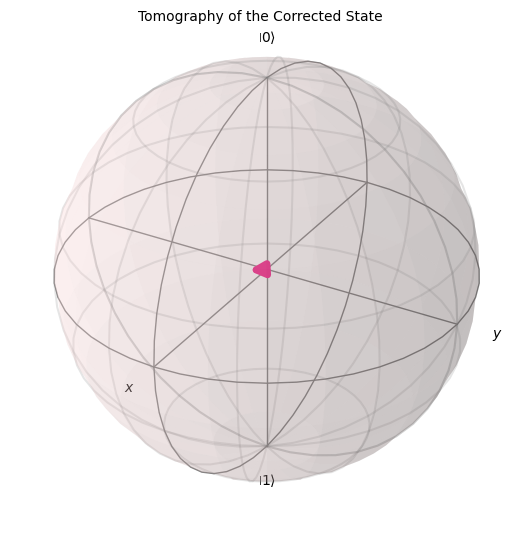

In [12]:
# 2. State Reconstruction
bases = ['Z', 'X', 'Y']
exp_values = {}

for idx, basis in enumerate(bases):
    counts = result[idx].data.final_measurement.get_counts()
    
    total_shots = sum(counts.values())
    
    p0 = counts.get('0', 0) / total_shots
    p1 = counts.get('1', 0) / total_shots
    
    exp_values[basis] = p0 - p1

# Create the 3D vector with coordinates [X, Y, Z]
bloch_coords = [exp_values['X'], exp_values['Y'], exp_values['Z']]
mean_value = np.array(bloch_coords)
print(f"Coordinates of the Bloch Vector [X, Y, Z]:")
print(f"X: {bloch_coords[0]:.3f}")
print(f"Y: {bloch_coords[1]:.3f}")
print(f"Z: {bloch_coords[2]:.3f}")

# 3. Drawing the Tomography
plot_bloch_vector(bloch_coords, title="Tomography of the Corrected State")

# Fidelity calculation for real hardware simulation

In [13]:
shots = 8192

print(f"Mean value for Z component: {mean_value[2]}")
print(f"Mean value for X component: {mean_value[0]}")
print(f"Mean value for Y component: {mean_value[1]}")

# Verify probability conservation
prob = mean_value[0] ** 2 + mean_value[1] ** 2 + mean_value[2] ** 2
print(f"Probability conservation (should be close to 1.0): {prob}")

# Plot the Bloch vector
vector = np.array([mean_value[0], mean_value[1], mean_value[2]])
plot_bloch_vector(vector, title='Bloch vector for the corrected state')


# Density matrix reconstruction from the measured Bloch vector components
rho_reconstructed = 0.5 * (
    np.eye(2) +
    mean_value[0] * np.array([[0,1],[1,0]]) +
    mean_value[1] * np.array([[0,-1j],[1j,0]]) +
    mean_value[2] * np.array([[1,0],[0,-1]])
)

# Ideal state as a density matrix vector
ideal = np.array([np.sqrt(3)/2, 1/2])
rho_ideal = np.outer(ideal, ideal)

# Fidelity F = Tr(rho_ideal @ rho_reconstructed)
fidelity = np.real(np.trace(rho_ideal @ rho_reconstructed))
print(f"Fidelity reconstructed: {fidelity:.6f}")

Mean value for Z component: 0.04541015625
Mean value for X component: 0.12744140625
Mean value for Y component: -0.040283203125
Probability conservation (should be close to 1.0): 0.019926130771636963
Fidelity reconstructed: 0.566536
